<a href="https://colab.research.google.com/github/CH3MLON/Data_GenAI_training/blob/main/day2/day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
ds = pd.read_csv("/content/student_performance.csv")
ds.shape

(30, 13)

In [3]:
ds.columns.to_list()

['student_id',
 'name',
 'age',
 'gender',
 'department',
 'semester',
 'math_score',
 'science_score',
 'english_score',
 'programming_score',
 'attendance_percentage',
 'city',
 'admission_year']

In [4]:
conn = sqlite3.connect('college.db')
cursor=conn.cursor()
ds.to_sql(
    "students",
    conn,
    if_exists="replace",
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(count)

30


In [5]:
cursor.execute("SELECT * FROM students WHERE department = 'Computer Science'")
result = cursor.fetchall()
for row in result:
    print(row)

(1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
(1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
(1005, 'Arjun Nair', 19, 'Male', 'Computer Science', 2, 92, 88, 81, 95, 90, 'Kochi', 2023)
(1008, 'Divya Singh', 19, 'Female', 'Computer Science', 2, 88, 91, 84, 93, 96, 'Lucknow', 2023)
(1010, 'Ananya Das', 19, 'Female', 'Computer Science', 2, 95, 89, 90, 97, 98, 'Kolkata', 2023)
(1013, 'Suresh Rao', 21, 'Male', 'Computer Science', 2, 83, 86, 77, 88, 88, 'Mysore', 2023)
(1015, 'Ajay Tiwari', 19, 'Male', 'Computer Science', 2, 71, 69, 64, 76, 75, 'Bhopal', 2023)
(1018, 'Swati Kulkarni', 19, 'Female', 'Computer Science', 2, 90, 87, 85, 92, 94, 'Nagpur', 2023)
(1020, 'Nisha Kapoor', 19, 'Female', 'Computer Science', 2, 79, 84, 81, 83, 89, 'Chandigarh', 2023)
(1022, 'Tanvi Mehta', 19, 'Female', 'Computer Science', 2, 93, 90, 88, 96, 97, 'Surat', 2023)
(1025, 'Amit Bose', 19, 'Male', 'Computer Science

In [6]:
query="""
  SELECT student_id,name,department,math_score,attendance_percentage
  FROM students
  LIMIT 10
"""
cursor.execute(query)
result = cursor.fetchall()

In [7]:
result

[(1001, 'Aarav Sharma', 'Computer Science', 85, 92),
 (1002, 'Priya Patel', 'Computer Science', 76, 87),
 (1003, 'Rohit Verma', 'Electronics', 65, 78),
 (1004, 'Sneha Reddy', 'Mechanical', 70, 95),
 (1005, 'Arjun Nair', 'Computer Science', 92, 90),
 (1006, 'Meera Joshi', 'Electronics', 58, 72),
 (1007, 'Kiran Kumar', 'Civil', 73, 85),
 (1008, 'Divya Singh', 'Computer Science', 88, 96),
 (1009, 'Rahul Mishra', 'Mechanical', 62, 68),
 (1010, 'Ananya Das', 'Computer Science', 95, 98)]

In [8]:
query2="""
SELECT
  department,
  COUNT(*) AS num_students,
  ROUND(AVG(math_score), 2) AS avg_math,
  ROUND(AVG(science_score), 2) AS avg_science,
  ROUND(AVG(attendance_percentage), 2) AS avg_attendance,
  ROUND(AVG(programming_score),2) AS avg_programming
FROM students
GROUP BY department
ORDER BY avg_math DESC;
"""
cursor.execute(query2)

In [9]:
result2 = cursor.fetchall()
print(result2)

[('Computer Science', 13, 85.62, 84.46, 90.69, 89.23), ('Mechanical', 6, 71.0, 76.5, 83.5, 49.33), ('Electronics', 6, 71.0, 74.17, 80.33, 61.5), ('Civil', 5, 63.4, 66.6, 74.6, 40.6)]


In [10]:
column_names = [description[0] for description in cursor.description]
df_result2 = pd.DataFrame(result2, columns=column_names)
display(df_result2)

,department,num_students,avg_math,avg_science,avg_attendance,avg_programming
0,Computer Science,13,85.62,84.46,90.69,89.23
1,Mechanical,6,71.00,76.50,83.50,49.33
2,Electronics,6,71.00,74.17,80.33,61.50
3,Civil,5,63.40,66.60,74.60,40.60


In [11]:
query3="""
SELECT
  department,
  ROUND(AVG(math_score), 2) AS avg_math,
  COUNT(*) AS num_students
FROM students
GROUP BY department
HAVING avg_math > 70
ORDER BY avg_math DESC
"""
cursor.execute(query3)
result3 = cursor.fetchall()

In [12]:
result3

[('Computer Science', 85.62, 13),
 ('Mechanical', 71.0, 6),
 ('Electronics', 71.0, 6)]

In [13]:
query4="""
SELECT
  gender,
  COUNT(*) AS num_students,
  ROUND(AVG(math_score), 2) AS avg_math,
  ROUND(AVG(programming_score), 2) AS avg_programming,
  ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_math DESC
"""
cursor.execute(query4)
result4 = cursor.fetchall()


In [14]:
result4

[('Female', 15, 78.47, 70.2, 88.53), ('Male', 15, 73.67, 65.0, 80.47)]

In [15]:
column_names4 = [description[0] for description in cursor.description]
df_result4 = pd.DataFrame(result4, columns=column_names4)
display(df_result4)

,gender,num_students,avg_math,avg_programming,avg_attendance
0,Female,15,78.47,70.2,88.53
1,Male,15,73.67,65.0,80.47


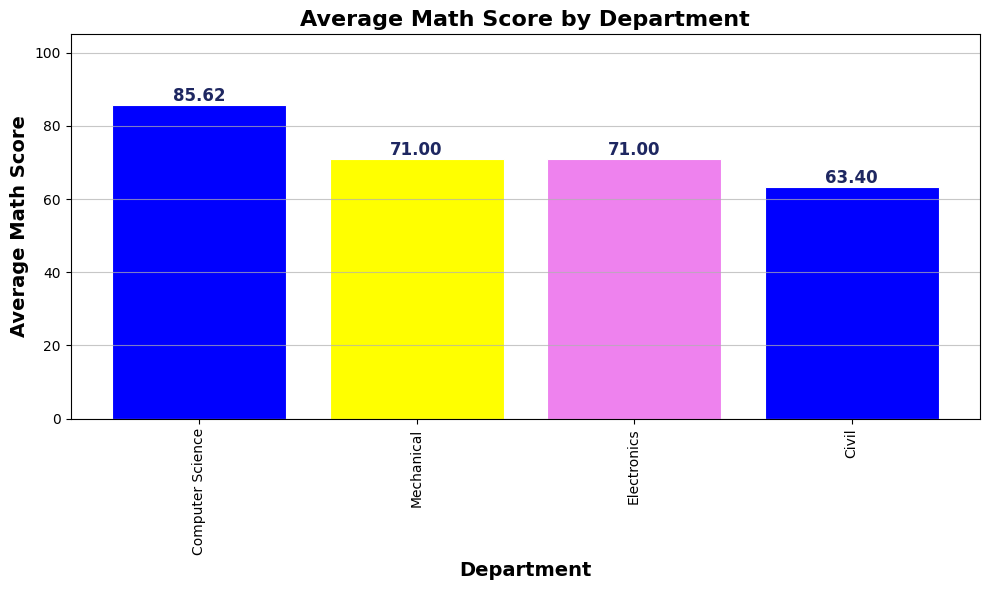

In [19]:
from numpy import linalg
chart1_sql="""
select
  department,
  ROUND(AVG(math_score),2) AS avg_math
  from students
  group by department
  order by avg_math desc
"""
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_color=["blue","yellow","violet"]
bars=ax.bar(chart1_data["department"],chart1_data["avg_math"],color=bar_color,edgecolor="white",linewidth=0.8)

for bar in bars:
  height=bar.get_height()
  ax.text(bar.get_x()+bar.get_width()/2,height,f"{height:.2f}",ha="center",va="bottom",fontsize=12,fontweight="bold",color="#1E2761")

ax.set_title("Average Math Score by Department",fontsize=16,fontweight="bold")
ax.set_xlabel("Department",fontsize=14,fontweight="bold")
ax.set_ylabel("Average Math Score",fontsize=14,fontweight="bold")
ax.set_ylim(0,105)
ax.tick_params(axis="x",labelrotation=90)
ax.grid(axis='y',linestyle='-',alpha=0.7)
plt.tight_layout()
plt.show()

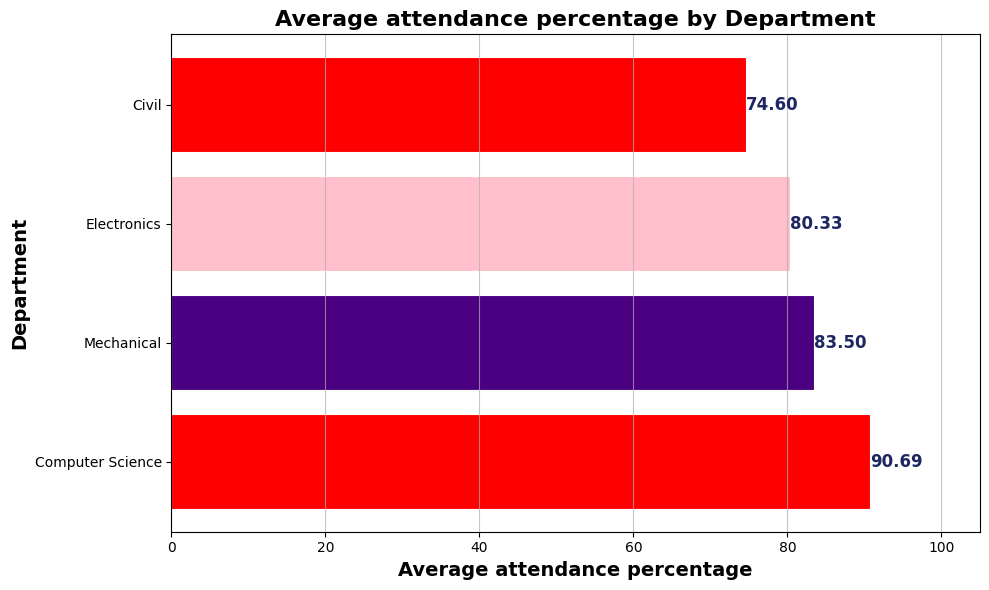

In [24]:
from numpy import linalg
chart1_sql="""
select
  department,
  ROUND(AVG(attendance_percentage),2) AS avg_attendance
  from students
  group by department
  order by avg_attendance desc

"""
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_color=["red","indigo","pink"]
bars=ax.barh(chart1_data["department"],chart1_data["avg_attendance"],color=bar_color,edgecolor="white",linewidth=0.8)

for bar in bars:
  width=bar.get_width()
  ax.text(width,bar.get_y()+bar.get_height()/2,f"{width:.2f}",ha="left",va="center",fontsize=12,fontweight="bold",color="#1E2761")

ax.set_title("Average attendance percentage by Department",fontsize=16,fontweight="bold")
ax.set_xlabel("Average attendance percentage",fontsize=14,fontweight="bold")
ax.set_ylabel("Department",fontsize=14,fontweight="bold")
ax.set_xlim(0,105)
ax.tick_params(axis="y",labelrotation=0)
ax.grid(axis='x',linestyle='-',alpha=0.7)
plt.tight_layout()
plt.show()

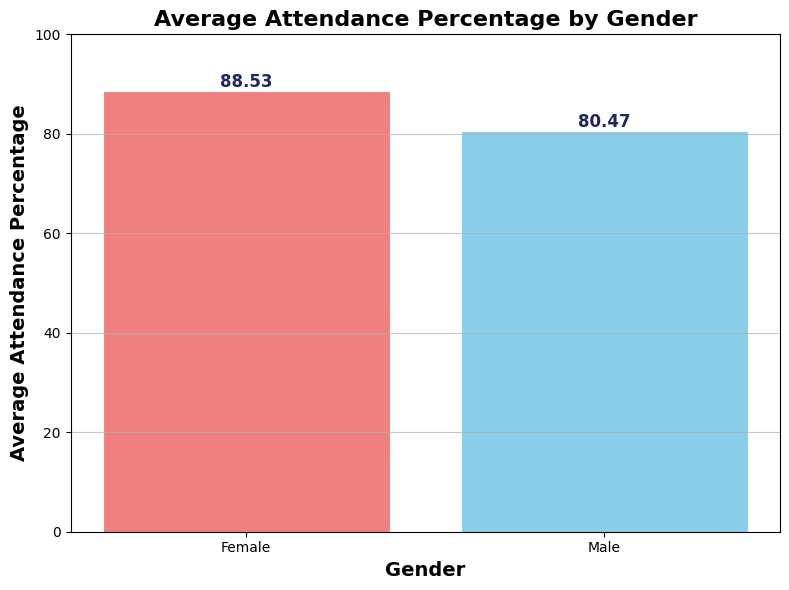

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = ["lightcoral", "skyblue"]
bars = ax.bar(df_result4["gender"], df_result4["avg_attendance"], color=bar_colors, edgecolor="white", linewidth=0.8)

for bar in bars:
  height = bar.get_height()
  ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", ha="center", va="bottom", fontsize=12, fontweight="bold", color="#1E2761")

ax.set_title("Average Attendance Percentage by Gender", fontsize=16, fontweight="bold")
ax.set_xlabel("Gender", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Attendance Percentage", fontsize=14, fontweight="bold")
ax.set_ylim(0, 100) # Attendance percentage usually goes up to 100
ax.tick_params(axis="x", labelrotation=0)
ax.grid(axis='y', linestyle='-', alpha=0.7)
plt.tight_layout()
plt.show()

In [27]:
department_student_count_sql = """
SELECT
  department,
  COUNT(*) AS num_students
FROM students
GROUP BY department
ORDER BY num_students DESC
"""
df_department_students = pd.read_sql_query(department_student_count_sql, conn)

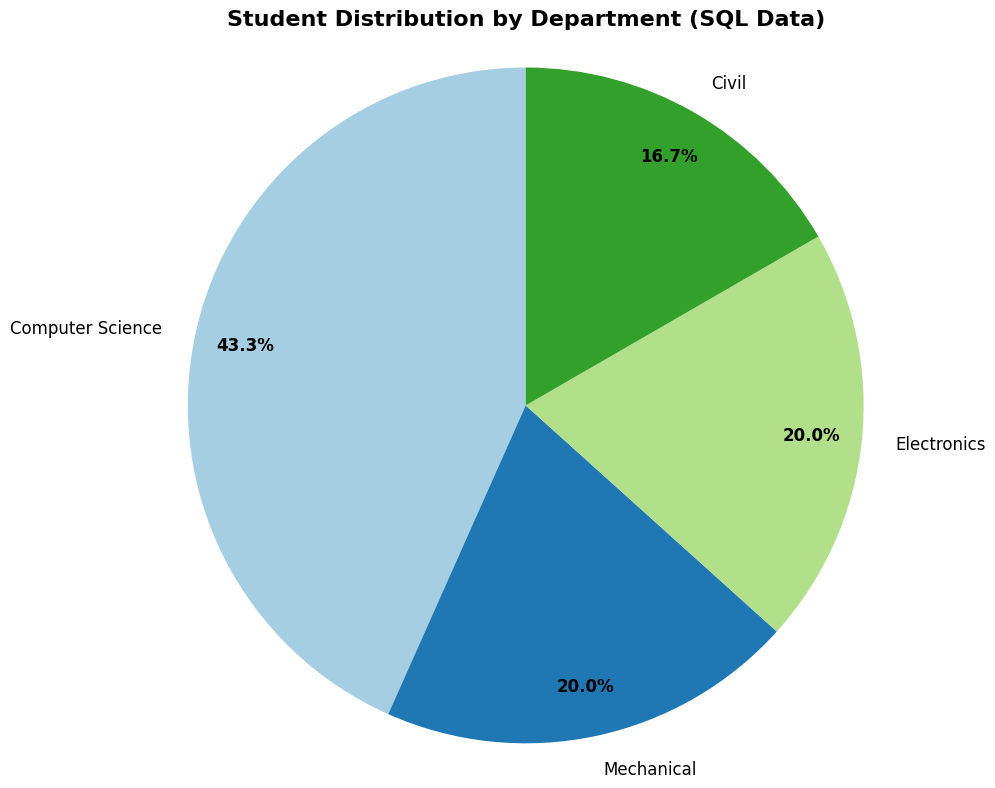

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))


wedges, texts, autotexts = ax.pie(df_department_students['num_students'],
                                  labels=df_department_students['department'],
                                  autopct='%1.1f%%',
                                  startangle=90,
                                  colors=plt.cm.Paired.colors,
                                  pctdistance=0.85)

ax.axis('equal')


ax.set_title("Student Distribution by Department (SQL Data)", fontsize=16, fontweight="bold")


for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_color('black')


for text in texts:
    text.set_fontsize(12)

plt.tight_layout()
plt.show()

In [35]:
query5="""
select
gender,
ROUND(AVG(programming_score),2) AS avg_programming
from students
GROUP BY gender
HAVING gender="Female"


"""
cursor.execute(query5)
result5 = cursor.fetchall()


In [36]:
result5

[('Female', 70.2)]

In [41]:
query6= """
select
department,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
from students
GROUP BY department
HAVING avg_attendance>85

"""
cursor.execute(query6)
result6 = cursor.fetchall()


In [42]:
result6

[('Computer Science', 90.69)]